In [1]:
import pandas as pd
import numpy as np

taxlevels = ['domain','phylum','class','order','family','genus','species']

phyla2plot = ['Firmicutes','Bacteroidota','Actinobacteriota','Proteobacteria']

Host associations by linkage method

In [2]:
df_pr = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='prophage', usecols=['votu_id','sample_id'] + taxlevels).drop_duplicates()
df_pr['linkage_method'] = 'pr'
df_sp = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='spacer matching', usecols=['votu_id','sample_id'] + taxlevels).drop_duplicates()
df_sp['linkage_method'] = 'sp'
df_hc = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='Hi-C', usecols=['votu_id','sample_id'] + taxlevels).drop_duplicates()
df_hc['linkage_method'] = 'hc'

df = pd.concat([df_pr, df_sp, df_hc], ignore_index=True)

Group Firmicutes, Firmicutes_A, Firmicutes_B, and Firmicutes_C as "Firmicutes" for host range specificity analysis, since they are closely related and often have similar phages infecting them.

In [3]:
df = df.rename(columns={'phylum': 'phylum0'})
df['phylum'] = np.where(df.phylum0.str.startswith('Firmicutes'), 'Firmicutes', df.phylum0)

In [4]:
df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC'])

df = df.merge(df_v, on='votu_id', how='left')

Compute Shannon entropy of hosts at each taxonomic level.

In [5]:
from scipy.stats import entropy

def calculate_vfc_entropy(df):
    cols = []
    for t in taxlevels:
        tmp = df[['VFC','votu_id', t]].drop_duplicates()
        s = tmp.groupby('VFC')[t].apply(lambda g: 
                entropy(g.value_counts(normalize=True), base=2))
        cols.append(s.rename(t + '_entropy'))
    return pd.concat(cols, axis=1).fillna(0).reset_index()

df_vfc_entropy = calculate_vfc_entropy(df)


In [6]:
df_vc = pd.read_excel('../data/Supplementary_Data_3_VFC_metadata.xlsx', usecols=['VFC','perc_prevalence','primary_host_phylum'])

df_vfc_entropy = df_vfc_entropy.merge(df_vc[['VFC','perc_prevalence','primary_host_phylum']], on='VFC', how='left')

"the 12 most prevalent VFCs in this study have **>4×** greater host diversity relative to other VFCs (**family-level entropy=1.2** versus **0.3**)"

In [7]:
mask = df_vfc_entropy.VFC.isin(range(1,13))

topvfc_entropy = df_vfc_entropy.loc[mask, 'family_entropy'].mean()
othervfc_entropy = df_vfc_entropy.loc[~mask, 'family_entropy'].mean()
print(f'Mean family entropy: top 12 VFCs = {topvfc_entropy:.1f}, other VFCs = {othervfc_entropy:.1f}; ratio = {topvfc_entropy/othervfc_entropy:.1f}')

Mean family entropy: top 12 VFCs = 1.2, other VFCs = 0.3; ratio = 4.1


### Supplementary Fig. 19AB: family and order-level host entropy of VFCs

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df_vfc_entropy['phylum_plot'] = df_vfc_entropy['primary_host_phylum'].where(df_vfc_entropy['primary_host_phylum'].isin(phyla2plot), 'Others')

sns.set_style('whitegrid')
sns.color_palette('deep')
hue_order = phyla2plot + ['Others']
palette = ['C3','C2','C0','C1','grey']

Family-level entropy

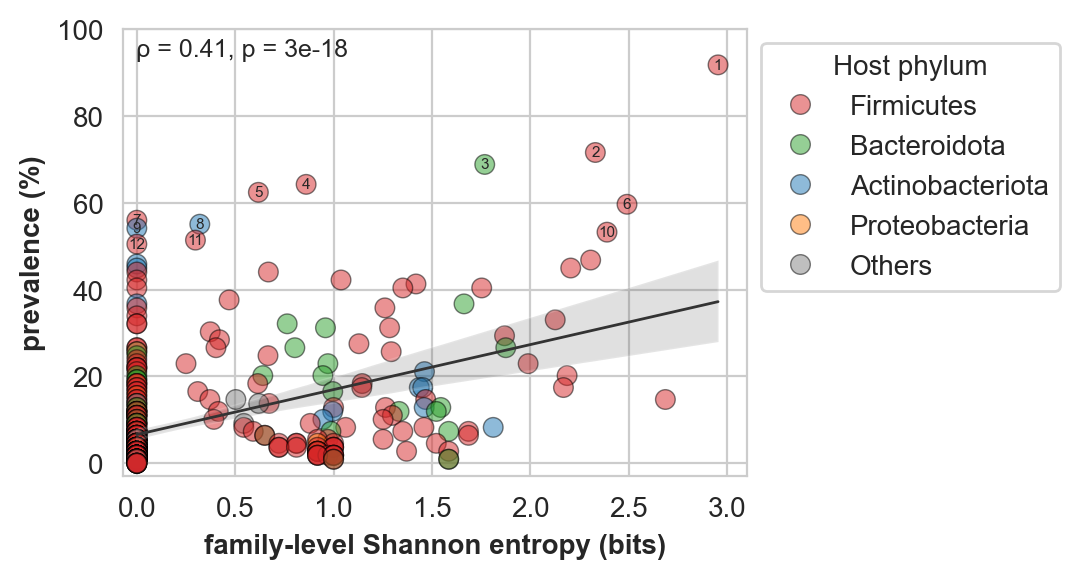

In [9]:
tlevel = 'family'

plt.figure(figsize=(5.5,3), dpi=200)

ax = sns.scatterplot(data=df_vfc_entropy, x=f'{tlevel}_entropy', y='perc_prevalence',
                hue='phylum_plot', hue_order=hue_order, palette=palette,
                s=50, edgecolor='k', linewidth=0.5, alpha=0.5,)

sns.regplot(data=df_vfc_entropy, x=f'{tlevel}_entropy', y='perc_prevalence',
            scatter=False, ax=ax, color='0.2', line_kws={'linewidth':1, 'linestyle':'-'})

from scipy.stats import spearmanr
rho, pval = spearmanr(df_vfc_entropy[f'{tlevel}_entropy'], df_vfc_entropy['perc_prevalence'])
ann_text = f'ρ = {rho:.2f}, p = {pval:.1g}'
ax.text(0.02, 0.98, ann_text, transform=ax.transAxes, ha='left', va='top',
        fontsize=9, bbox=dict(facecolor='white', alpha=0, edgecolor='none'))

label_vfcs = list(range(1,13))
for _, row in df_vfc_entropy[df_vfc_entropy['VFC'].isin(label_vfcs)].iterrows():
    ax.text(row[f'{tlevel}_entropy'] , row['perc_prevalence'], str(int(row['VFC'])),
            fontsize=5.5, ha='center', va='center')

plt.xlabel(f'{tlevel}-level Shannon entropy (bits)', fontweight='bold')
plt.ylabel('prevalence (%)', fontweight='bold')

xmin, xmax = plt.xlim()
plt.xlim(0-0.07,xmax)
plt.ylim(0-3,100)

plt.legend(title='Host phylum', bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()

Order-level entropy

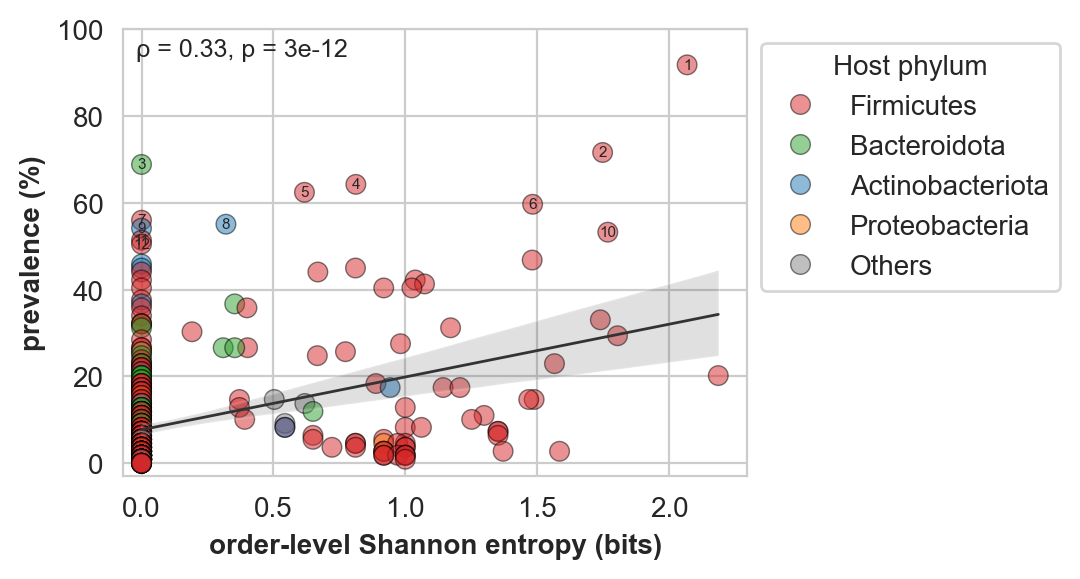

In [10]:
tlevel = 'order'

plt.figure(figsize=(5.5,3), dpi=200)

ax = sns.scatterplot(data=df_vfc_entropy, x=f'{tlevel}_entropy', y='perc_prevalence',
                hue='phylum_plot', hue_order=hue_order, palette=palette,
                s=50, edgecolor='k', linewidth=0.5, alpha=0.5,)

sns.regplot(data=df_vfc_entropy, x=f'{tlevel}_entropy', y='perc_prevalence',
            scatter=False, ax=ax, color='0.2', line_kws={'linewidth':1, 'linestyle':'-'})

from scipy.stats import spearmanr
rho, pval = spearmanr(df_vfc_entropy[f'{tlevel}_entropy'], df_vfc_entropy['perc_prevalence'])
ann_text = f'ρ = {rho:.2f}, p = {pval:.1g}'
ax.text(0.02, 0.98, ann_text, transform=ax.transAxes, ha='left', va='top',
        fontsize=9, bbox=dict(facecolor='white', alpha=0, edgecolor='none'))

label_vfcs = list(range(1,13))
for _, row in df_vfc_entropy[df_vfc_entropy['VFC'].isin(label_vfcs)].iterrows():
    ax.text(row[f'{tlevel}_entropy'] , row['perc_prevalence'], str(int(row['VFC'])),
            fontsize=5.5, ha='center', va='center')

plt.xlabel(f'{tlevel}-level Shannon entropy (bits)', fontweight='bold')
plt.ylabel('prevalence (%)', fontweight='bold')

xmin, xmax = plt.xlim()
plt.xlim(0-0.07,xmax)
plt.ylim(0-3,100)

plt.legend(title='Host phylum', bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()